In [ ]:
import pandas as pd

df = pd.read_csv('/content/processed_insurance.csv')

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


In [ ]:
df['risk_level'] = pd.qcut(
    df['charges'],
    q=3,
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

df[['charges', 'risk_level']].head()

,charges,risk_level
0,16884.92400,High Risk
1,1725.55230,Low Risk
2,4449.46200,Low Risk
3,21984.47061,High Risk
4,3866.85520,Low Risk


In [ ]:
df['risk_level'].value_counts()

,count
risk_level,
Low Risk,446
High Risk,446
Medium Risk,445


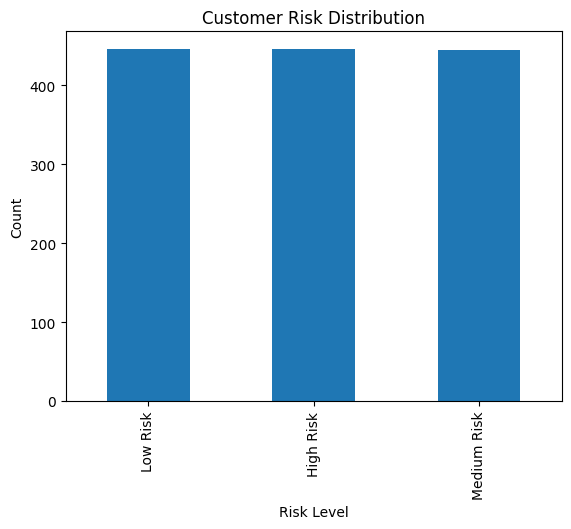

In [ ]:
import matplotlib.pyplot as plt

df['risk_level'].value_counts().plot(
    kind='bar'
)

plt.title('Customer Risk Distribution')
plt.xlabel('Risk Level')
plt.ylabel('Count')

plt.show()

In [ ]:
df.groupby('risk_level')['charges'].describe()

/tmp/ipykernel_1502/1991328110.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('risk_level')['charges'].describe()


,count,mean,std,min,25%,50%,75%,max
risk_level,,,,,,,,
Low Risk,446.0,3508.424306,1465.480898,1121.8739,2174.16730,3393.166575,4744.32505,6272.47720
Medium Risk,445.0,9426.201073,1903.742896,6282.2350,7729.64575,9386.161300,11093.62290,12815.44495
High Risk,446.0,26894.100246,11757.466870,12829.4551,16687.36410,23353.926375,37120.26665,63770.42801


In [ ]:
pd.crosstab(
    df['smoker'],
    df['risk_level']
)

risk_level,Low Risk,Medium Risk,High Risk
smoker,,,
0,446,445,172
1,0,0,274


In [ ]:
df.groupby('risk_level')['age'].mean()

/tmp/ipykernel_1502/3061041104.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('risk_level')['age'].mean()


,age
risk_level,
Low Risk,26.520179
Medium Risk,47.957303
High Risk,43.208520


In [ ]:
risk_df = df.copy()

risk_df.to_csv(
    '/content/risk_classification_dataset.csv',
    index=False
)

In [ ]:
def recommend_policy(risk):
    if risk == "Low Risk":
        return "Basic Insurance Plan"
    elif risk == "Medium Risk":
        return "Standard Insurance Plan"
    else:
        return "Premium Insurance Plan"

df['recommended_policy'] = df['risk_level'].apply(
    recommend_policy
)

df[['risk_level', 'recommended_policy']].head()

,risk_level,recommended_policy
0,High Risk,Premium Insurance Plan
1,Low Risk,Basic Insurance Plan
2,Low Risk,Basic Insurance Plan
3,High Risk,Premium Insurance Plan
4,Low Risk,Basic Insurance Plan
